
[![Electronic Profile](https://img.shields.io/badge/Electronic%20Profile-engineer--e-181717?logo=github)](https://github.com/engineer-e/) 
[![Work Profile](https://img.shields.io/badge/Work%20Profile-engineer--work-181717?logo=github)](https://github.com/engineer-work/) 
[![Instagram](https://img.shields.io/badge/Instagram-gobalkrishnan.engineer-E4405F?logo=instagram&logoColor=white)](https://www.instagram.com/gobalkrishnan.engineer/)

# 4. Rays, a Simple Camera, and Background


## 4.2 Sending Rays Into the Scene



Good. You’re at the exact point where ray tracing starts.

I’ll convert this into **Python step-by-step**, with:

1. **Formula**
2. **Purpose**
3. **Meaning**
4. **Python code**
5. **Table format**
6. **LaTeX formulas**

---

# 1. Big Idea of Ray Tracing

Ray tracing does 3 main jobs:

| Step              | Formula                        | Meaning                                     | Purpose             |
| ----------------- | ------------------------------ | ------------------------------------------- | ------------------- |
| Create ray        | $$R(t)=O+tD$$                  | Ray starts at origin and moves in direction | Send ray into world |
| Find intersection | Solve object equation with ray | Check hit                                   | Detect object       |
| Compute color     | Based on hit or sky            | Paint pixel                                 | Final image         |

---

# 2. Camera System

Your camera is:

$$Camera=(0,0,0)$$

Looking toward:

$$-Z$$

Coordinate system:

| Axis | Direction |
| ---- | --------- |
| X    | Right     |
| Y    | Up        |
| Z    | Toward us |
| -Z   | Forward   |

---

# 3. Image Aspect Ratio

Formula:

$$AspectRatio=\frac{Width}{Height}$$

Given:

$$AspectRatio=\frac{16}{9}$$

Python:

```python
aspect_ratio = 16 / 9
image_width = 400
image_height = int(image_width / aspect_ratio)

if image_height < 1:
    image_height = 1
```

---

### Table Explanation

| Formula                      | Description               | Purpose            |
| ---------------------------- | ------------------------- | ------------------ |
| $$\frac{W}{H}=\frac{16}{9}$$ | Keeps image shape correct | Prevent stretching |

Example:

$$Height=\frac{400}{16/9}=225$$

---

# 4. Viewport

Viewport = virtual screen in 3D.

We choose:

$$ViewportHeight=2.0$$

Width:

$$ViewportWidth=ViewportHeight \cdot \frac{ImageWidth}{ImageHeight}$$

Python:

```python
viewport_height = 2.0
viewport_width = viewport_height * (image_width / image_height)
```

---

### Table

| Formula                        | Meaning                 |
| ------------------------------ | ----------------------- |
| $$V_w=V_h \times \frac{W}{H}$$ | Match viewport to image |

---

# 5. Focal Length

Distance from eye to viewport:

$$f=1.0$$

Purpose:

Controls how far the image plane is.

Python:

```python
focal_length = 1.0
```

---

| Formula | Purpose                   |
| ------- | ------------------------- |
| $$f=1$$ | Distance camera to screen |

---

# 6. Viewport Vectors

Horizontal:

$$V_u=(ViewportWidth,0,0)$$

Vertical:

$$V_v=(0,-ViewportHeight,0)$$

Why negative?

Because image Y goes downward.

Python:

```python
viewport_u = [viewport_width, 0, 0]
viewport_v = [0, -viewport_height, 0]
```

---

### Table

| Vector     | Formula          | Purpose    |
| ---------- | ---------------- | ---------- |
| Horizontal | $$V_u=(w,0,0)$$  | Move right |
| Vertical   | $$V_v=(0,-h,0)$$ | Move down  |

---

# 7. Pixel Size

Horizontal pixel gap:

$$\Delta u=\frac{V_u}{ImageWidth}$$

Vertical pixel gap:

$$\Delta v=\frac{V_v}{ImageHeight}$$

Python:

```python
pixel_delta_u = [viewport_u[0] / image_width, 0, 0]
pixel_delta_v = [0, viewport_v[1] / image_height, 0]
```

---

### Table

| Formula                    | Meaning               |
| -------------------------- | --------------------- |
| $$\Delta u=\frac{V_u}{W}$$ | Horizontal pixel step |
| $$\Delta v=\frac{V_v}{H}$$ | Vertical pixel step   |

---

# 8. Viewport Upper Left

Formula:

$$Q=C-(0,0,f)-\frac{V_u}{2}-\frac{V_v}{2}$$

Where:

* $C$ = camera

Python:

```python
camera_center = [0,0,0]

viewport_upper_left = [
    camera_center[0] - viewport_u[0]/2,
    camera_center[1] - viewport_v[1]/2,
    camera_center[2] - focal_length
]
```

---

### Table

| Formula                                     | Purpose              |
| ------------------------------------------- | -------------------- |
| $$Q=C-(0,0,f)-\frac{V_u}{2}-\frac{V_v}{2}$$ | Find top-left corner |

---

# 9. First Pixel Center

Formula:

$$P_{0,0}=Q+\frac{1}{2}(\Delta u+\Delta v)$$

Python:

```python
pixel00 = [
    viewport_upper_left[0] + 0.5 * pixel_delta_u[0],
    viewport_upper_left[1] + 0.5 * pixel_delta_v[1],
    viewport_upper_left[2]
]
```

---

### Table

| Formula                                  | Meaning            |
| ---------------------------------------- | ------------------ |
| $$P_{0,0}=Q+\frac12(\Delta u+\Delta v)$$ | First pixel center |

---

# 10. Pixel Location

For any pixel:

$$P(i,j)=P_{0,0}+i\Delta u+j\Delta v$$

Python:

```python
pixel_center_x = pixel00[0] + i * pixel_delta_u[0]
pixel_center_y = pixel00[1] + j * pixel_delta_v[1]
pixel_center_z = pixel00[2]
```

---

### Table

| Formula                                | Purpose             |
| -------------------------------------- | ------------------- |
| $$P(i,j)=P_{0,0}+i\Delta u+j\Delta v$$ | Find pixel position |

---

# 11. Ray Formula

Ray:

$$R(t)=O+tD$$

Where:

$$O=CameraCenter$$

$$D=PixelCenter-CameraCenter$$

Python:

```python
ray_origin = camera_center

ray_direction = [
    pixel_center_x - ray_origin[0],
    pixel_center_y - ray_origin[1],
    pixel_center_z - ray_origin[2]
]
```

---

### Table

| Formula       | Meaning      |
| ------------- | ------------ |
| $$R(t)=O+tD$$ | Ray equation |

---

# 12. Normalize Direction

Formula:

$$\hat D=\frac{D}{|D|}$$

Magnitude:

$$|D|=\sqrt{x^2+y^2+z^2}$$

Python:

```python
import math

length = math.sqrt(
    ray_direction[0]**2 +
    ray_direction[1]**2 +
    ray_direction[2]**2
)

unit_direction = [
    ray_direction[0]/length,
    ray_direction[1]/length,
    ray_direction[2]/length
]
```

---


# 13. Gradient Color

Map Y from:

$$[-1,1] \to [0,1]$$

Formula:

$$a=0.5(y+1)$$

Lerp:

$$Color=(1-a)White+aBlue$$

Expanded:

$$Color=(1-a)(1,1,1)+a(0.5,0.7,1.0)$$

Python:

```python
a = 0.5 * (unit_direction[1] + 1.0)

white = [1.0, 1.0, 1.0]
blue = [0.5, 0.7, 1.0]

color = [
    (1-a)*white[0] + a*blue[0],
    (1-a)*white[1] + a*blue[1],
    (1-a)*white[2] + a*blue[2]
]
```

---

### Table

| Formula         | Purpose         |
| --------------- | --------------- |
| $$a=0.5(y+1)$$  | Convert Y range |
| $$L=(1-a)A+aB$$ | Blend colors    |

---

# Full Flow

| Step           | Formula                       | 
| -------------- | ----------------------------- | 
| Aspect ratio   | $$\frac{W}{H}$$               | 
| Viewport       | $$V_w=V_h\cdot \frac{W}{H}$$  | 
| Pixel delta    | $$\Delta=\frac{V}{N}$$        | 
| Pixel location | $$P=P_0+i\Delta u+j\Delta v$$ | 
| Ray            | $$R(t)=O+tD$$                 | 
| Normalize      | $$\hat D=\frac{D}{D}$$        | 
| Blend          | $$C=(1-a)A+aB$$               | 

---

This is the **foundation of all ray tracers**:

Camera → Viewport → Pixels → Rays → Objects → Color.

# Ray tracer             Human eye
----------------------------------------
1. Camera center    →     Pupil / lens center
2. Viewport         →     Retina
3. Pixel            →     Photoreceptor cells
4. Ray              →     Line of sight / incoming light path
5. Object           →     External world
6. Color            →     Signal to brain


In [1]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

from util.ray import Ray
from util.vec3 import Vec3
from util.color import write_color
from util.vec3 import unit_vector


In [2]:

# -----------------------------
# Sky color function
# -----------------------------
def ray_color(ray):
    unit_direction = unit_vector(ray.direction())

    # scale y from [-1,1] to [0,1]
    a = 0.5 * (unit_direction.y + 1.0)

    white = Vec3(1.0, 1.0, 1.0)
    blue = Vec3(0.5, 0.7, 1.0)

    # lerp
    return white * (1.0 - a) + blue * a

In [3]:
# -----------------------------
# IMAGE / CAMERA SETUP
# -----------------------------

# Aspect ratio of the final image (width : height)
# Example: 16:9 widescreen
aspect_ratio = 16.0 / 9.0

# Total number of horizontal pixels
image_width = 400

# Compute vertical pixels based on aspect ratio
image_height = int(image_width / aspect_ratio)


# -----------------------------
# CAMERA / VIEWPORT CONFIGURATION
# -----------------------------

# Distance between camera center and viewport
# This acts like "eye to retina" distance (focal length)
focal_length = 0.5

# Physical height of the viewport in world space
viewport_height = 2.0

# Physical width of viewport, scaled by aspect ratio
viewport_width = viewport_height * (image_width / image_height)

# Camera position (origin point)
# Think of this as the eye location
camera_center = Vec3(0, 0, 0)


# -----------------------------
# VIEWPORT AXIS VECTORS
# -----------------------------

# Horizontal vector of viewport
# Goes left → right
viewport_u = Vec3(viewport_width, 0, 0)

# Vertical vector of viewport
# Negative y means top → down
viewport_v = Vec3(0, -viewport_height, 0)


# -----------------------------
# PIXEL SIZE IN WORLD SPACE
# -----------------------------

# Width of one pixel in viewport space
pixel_delta_u = viewport_u / image_width

# Height of one pixel in viewport space
pixel_delta_v = viewport_v / image_height


# -----------------------------
# VIEWPORT POSITIONING
# -----------------------------

# Find the top-left corner of the viewport
#
# Steps:
# 1. Move forward along z-axis by focal length
# 2. Shift left by half viewport width
# 3. Shift up by half viewport height
viewport_upper_left = (
    camera_center
    - Vec3(0, 0, focal_length)
    - viewport_u / 2
    - viewport_v / 2
)


# -----------------------------
# FIRST PIXEL CENTER
# -----------------------------

# Move half pixel right and half pixel down
# so rays pass through the center of pixel (0,0)
pixel00_loc = viewport_upper_left + (
    (pixel_delta_u + pixel_delta_v) * 0.5
)


# -----------------------------
# SAVE IMAGE FILE (PPM FORMAT)
# -----------------------------

# Open output file in write mode
with open("output.ppm", "w") as f:

    # PPM Header:
    # P3 = plain text RGB format
    # width height
    # max color value
    f.write(f"P3\n{image_width} {image_height}\n255\n")


    # -----------------------------
    # LOOP THROUGH EACH PIXEL
    # -----------------------------
    
    # j = row (top to bottom)
    for j in range(image_height):

        # i = column (left to right)
        for i in range(image_width):


            # -----------------------------
            # COMPUTE CURRENT PIXEL POSITION
            # -----------------------------
            
            # Start from first pixel and move:
            # i steps horizontally
            # j steps vertically
            pixel_center = (
                pixel00_loc
                + pixel_delta_u * i
                + pixel_delta_v * j
            )


            # -----------------------------
            # CREATE RAY
            # -----------------------------
            
            # Ray direction = pixel position - camera position
            # This shoots a ray from eye → pixel
            ray_direction = pixel_center - camera_center

            # Create ray object
            r = Ray(camera_center, ray_direction)


            # -----------------------------
            # GET COLOR FOR THIS RAY
            # -----------------------------
            
            # Trace ray into scene
            # ray_color() decides what color it sees
            pixel_color = ray_color(r)


            # -----------------------------
            # CONVERT FLOAT COLORS TO 0–255
            # -----------------------------
            
            ir = int(255.999 * pixel_color.x)  # Red
            ig = int(255.999 * pixel_color.y)  # Green
            ib = int(255.999 * pixel_color.z)  # Blue


            # -----------------------------
            # WRITE PIXEL TO IMAGE
            # -----------------------------
            
            f.write(f"{ir} {ig} {ib}\n")


# Rendering complete
print("Done!")

Done!






# Pipeline flow:



**Camera (eye)** → **Viewport (retina/window)** → **Pixel center** → **Ray direction** → **Ray hits scene** → **Compute color** → **Write image**



Your analogy:



* **Eye** = `camera_center`

* **Pupil to retina distance** = `focal_length`

* **Retina/window** = `viewport`

* **Each retina cell** = pixel

* **Vision line** = ray



That mapping is correct for understanding ray tracing.

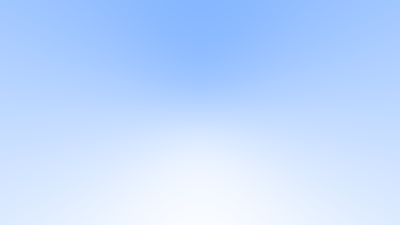

In [4]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")
from util.image_viewer import image_viewer
from util.scale_image import scale

a = image_viewer("output.ppm")
a